# Análisis exploratorio de la evolución climática en Aguascalientes (2003–2025)

## Calidad de datos, análisis temporal y visualización geoespacial

**Proyecto:** Factores asociados al éxito de la producción agrícola en México

**Fuente climática:** Open-Meteo Historical Weather API, modelo ERA5

**Fuente geográfica:** INEGI

### Objetivo

Evaluar la calidad y consistencia de los registros climáticos de los
municipios de Aguascalientes durante el periodo 2003–2025 y analizar
la evolución de sus temperaturas mediante series temporales y mapas.

### Variables principales

- Temperatura media anual (°C).
- Temperatura máxima anual (°C).
- Temperatura mínima anual (°C).

### Unidad de análisis

Municipio–año.

Las observaciones climáticas corresponden a coordenadas
representativas de cada municipio. No representan necesariamente
la temperatura promedio de toda su superficie.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from proyecto_agronomia.config import (
    CLIMA_RAW_DIR,
    INEGI_INTERIM_DIR,
)

from proyecto_agronomia.datasets.inegi import (
    obtener_municipios_inegi,
)

pd.set_option("display.max_columns", None)

2026-10-10 17:16:21.892 | INFO     | proyecto_agronomia.config:<module>:14 - PROJ_ROOT path is: B:\MCD2\JW\agro\proyecto_agronomia


In [2]:
RUTA_CLIMA = CLIMA_RAW_DIR / "clima_01_aguascalientes.csv"

clima_ags = pd.read_csv(RUTA_CLIMA)

print("Dimensiones:", clima_ags.shape)
print("Columnas:", clima_ags.columns.tolist())
print("Periodo:", clima_ags["Anio"].min(), "-", clima_ags["Anio"].max())
print("Municipios:", clima_ags["Idmunicipio"].nunique())

display(clima_ags.head())

Dimensiones: (253, 13)
Columnas: ['Anio', 'Temperatura_media', 'Temperatura_maxima', 'Temperatura_minima', 'Precipitacion_anual', 'Dias_con_lluvia', 'Horas_precipitacion', 'Evapotranspiracion_anual', 'Idestado', 'Idmunicipio', 'Nommunicipio', 'Latitud', 'Longitud']
Periodo: 2003 - 2025
Municipios: 11


,Anio,Temperatura_media,Temperatura_maxima,Temperatura_minima,Precipitacion_anual,Dias_con_lluvia,Horas_precipitacion,Evapotranspiracion_anual,Idestado,Idmunicipio,Nommunicipio,Latitud,Longitud
0,2003,19.62,36.0,1.5,664.7,112,820.0,1848.37,1,1,Aguascalientes,21.848487,-102.305449
1,2004,18.52,34.2,0.3,651.8,141,889.0,1756.49,1,1,Aguascalientes,21.848487,-102.305449
2,2005,19.60,36.5,3.4,379.7,107,571.0,1910.89,1,1,Aguascalientes,21.848487,-102.305449
3,2006,19.35,34.4,-1.3,584.1,126,798.0,1841.46,1,1,Aguascalientes,21.848487,-102.305449
4,2007,19.43,34.5,2.9,575.0,116,754.0,1847.47,1,1,Aguascalientes,21.848487,-102.305449


In [3]:
# 1. Valores faltantes
print("Valores faltantes:")
display(clima_ags.isna().sum().to_frame("Faltantes"))

# 2. Duplicados municipio-año
duplicados = clima_ags.duplicated(
    subset=["Idestado", "Idmunicipio", "Anio"]
).sum()

print("Duplicados municipio-año:", duplicados)

# 3. Cobertura temporal por municipio
cobertura = (
    clima_ags.groupby(["Idmunicipio", "Nommunicipio"])
    .agg(
        Primer_anio=("Anio", "min"),
        Ultimo_anio=("Anio", "max"),
        Anios_disponibles=("Anio", "nunique"),
    )
    .reset_index()
)

cobertura["Completo"] = (
    (cobertura["Primer_anio"] == 2003)
    & (cobertura["Ultimo_anio"] == 2025)
    & (cobertura["Anios_disponibles"] == 23)
)

display(cobertura)

# 4. Coherencia de temperaturas
temperaturas_invalidas = (
    (clima_ags["Temperatura_minima"] > clima_ags["Temperatura_media"])
    | (clima_ags["Temperatura_media"] > clima_ags["Temperatura_maxima"])
)

print(
    "Registros con temperaturas inconsistentes:",
    temperaturas_invalidas.sum()
)

Valores faltantes:


,Faltantes
Anio,0
Temperatura_media,0
Temperatura_maxima,0
Temperatura_minima,0
Precipitacion_anual,0
Dias_con_lluvia,0
Horas_precipitacion,0
Evapotranspiracion_anual,0
Idestado,0
Idmunicipio,0


Duplicados municipio-año: 0


,Idmunicipio,Nommunicipio,Primer_anio,Ultimo_anio,Anios_disponibles,Completo
0,1,Aguascalientes,2003,2025,23,True
1,2,Asientos,2003,2025,23,True
2,3,Calvillo,2003,2025,23,True
3,4,Cosío,2003,2025,23,True
4,5,Jesús María,2003,2025,23,True
5,6,Pabellón de Arteaga,2003,2025,23,True
6,7,Rincón de Romos,2003,2025,23,True
7,8,San José de Gracia,2003,2025,23,True
8,9,Tepezalá,2003,2025,23,True
9,10,El Llano,2003,2025,23,True


Registros con temperaturas inconsistentes: 0


## 2. Análisis geoespacial con GeoPandas

Utilizaremos las geometrías municipales de INEGI para representar
espacialmente los registros climáticos de Aguascalientes.

Los datos climáticos contienen identificadores de estado y municipio,
por lo que podemos asociar cada observación con su polígono geográfico.

La unión se realizará utilizando las claves `Idestado` e `Idmunicipio`,
evitando depender de los nombres municipales, que pueden presentar
diferencias de escritura.

In [4]:
# Cargar geometrías municipales de INEGI
municipios_geo = obtener_municipios_inegi()

# Seleccionar Aguascalientes (clave estatal 01)
ags_geo = municipios_geo[
    municipios_geo["cve_ent"].astype(str).str.zfill(2) == "01"
].copy()

print("Municipios de Aguascalientes:", len(ags_geo))
print("CRS:", ags_geo.crs)

display(
    ags_geo[
        ["cvegeo", "cve_ent", "cve_mun", "nomgeo"]
    ].head()
)

2026-10-10 17:17:57.683 | INFO     | proyecto_agronomia.datasets.inegi:obtener_municipios_inegi:29 - Cargando municipios INEGI desde archivo local.
Municipios de Aguascalientes: 11
CRS: EPSG:4326


,cvegeo,cve_ent,cve_mun,nomgeo
0,01001,01,001,Aguascalientes
1,01008,01,008,San José de Gracia
2,01011,01,011,San Francisco de los Romo
3,01009,01,009,Tepezalá
4,01007,01,007,Rincón de Romos


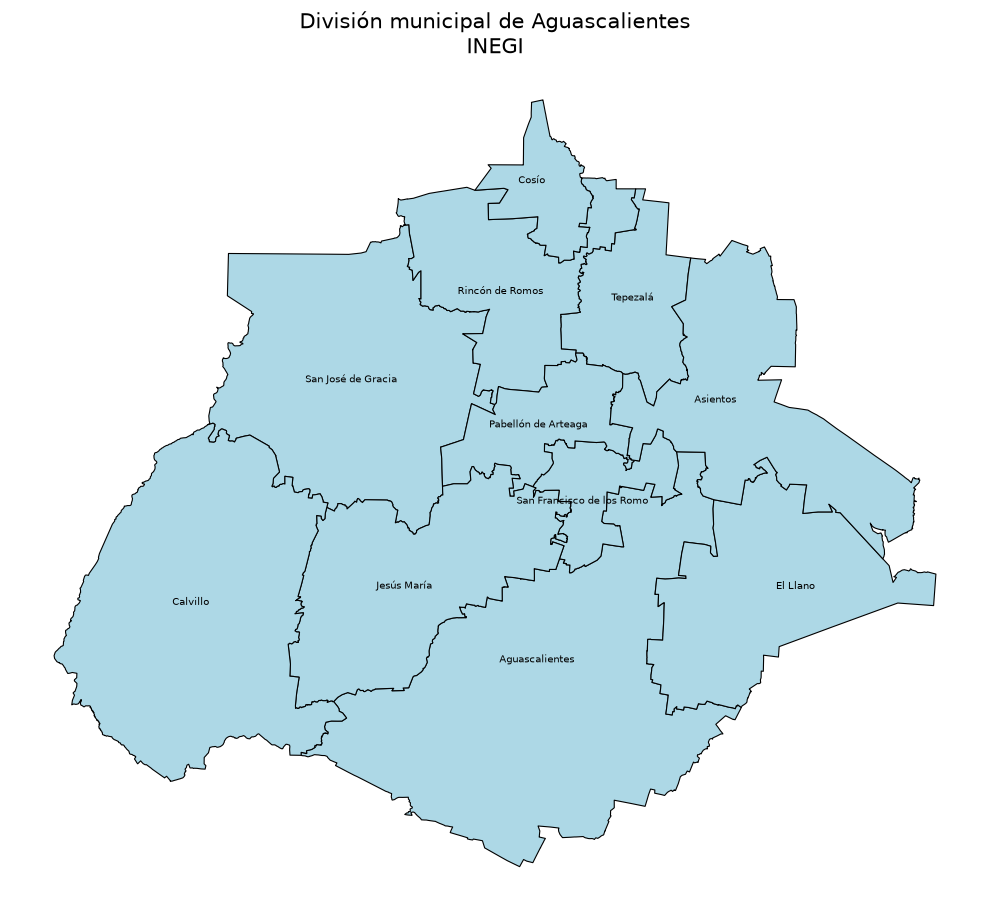

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

ags_geo.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="black",
    linewidth=0.8,
)

# Etiquetas dentro de cada municipio
puntos = ags_geo.to_crs("EPSG:6372").representative_point()
puntos = gpd.GeoSeries(puntos, crs="EPSG:6372").to_crs(ags_geo.crs)

for nombre, punto in zip(ags_geo["nomgeo"], puntos):
    ax.annotate(
        nombre,
        xy=(punto.x, punto.y),
        fontsize=7,
        ha="center",
        va="center",
    )

ax.set_title(
    "División municipal de Aguascalientes\nINEGI",
    fontsize=15,
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
# Convertir claves de INEGI a enteros
ags_geo["Idestado"] = ags_geo["cve_ent"].astype(int)
ags_geo["Idmunicipio"] = ags_geo["cve_mun"].astype(int)

# Comprobar unicidad de las geometrías
print(
    "Claves municipales duplicadas:",
    ags_geo.duplicated(
        ["Idestado", "Idmunicipio"]
    ).sum()
)

# Seleccionar temperaturas de 2025 para una primera prueba
clima_2025 = clima_ags[
    clima_ags["Anio"] == 2025
].copy()

# Unión por claves oficiales
ags_clima_2025 = ags_geo.merge(
    clima_2025[
        [
            "Idestado",
            "Idmunicipio",
            "Temperatura_media",
            "Temperatura_maxima",
            "Temperatura_minima",
        ]
    ],
    on=["Idestado", "Idmunicipio"],
    how="left",
    validate="one_to_one",
)

print("Municipios unidos:", len(ags_clima_2025))
print(
    "Municipios sin temperatura:",
    ags_clima_2025["Temperatura_media"].isna().sum()
)

display(
    ags_clima_2025[
        ["nomgeo", "Temperatura_media", "Temperatura_maxima"]
    ]
)

Claves municipales duplicadas: 0
Municipios unidos: 11
Municipios sin temperatura: 0


,nomgeo,Temperatura_media,Temperatura_maxima
0,Aguascalientes,20.21,35.5
1,San José de Gracia,17.10,33.4
2,San Francisco de los Romo,19.65,35.6
3,Tepezalá,18.88,35.1
4,Rincón de Romos,19.02,35.3
5,Pabellón de Arteaga,19.70,35.6
6,Cosío,18.72,35.0
7,Jesús María,18.66,35.0
8,El Llano,19.08,34.5
9,Calvillo,19.92,36.1


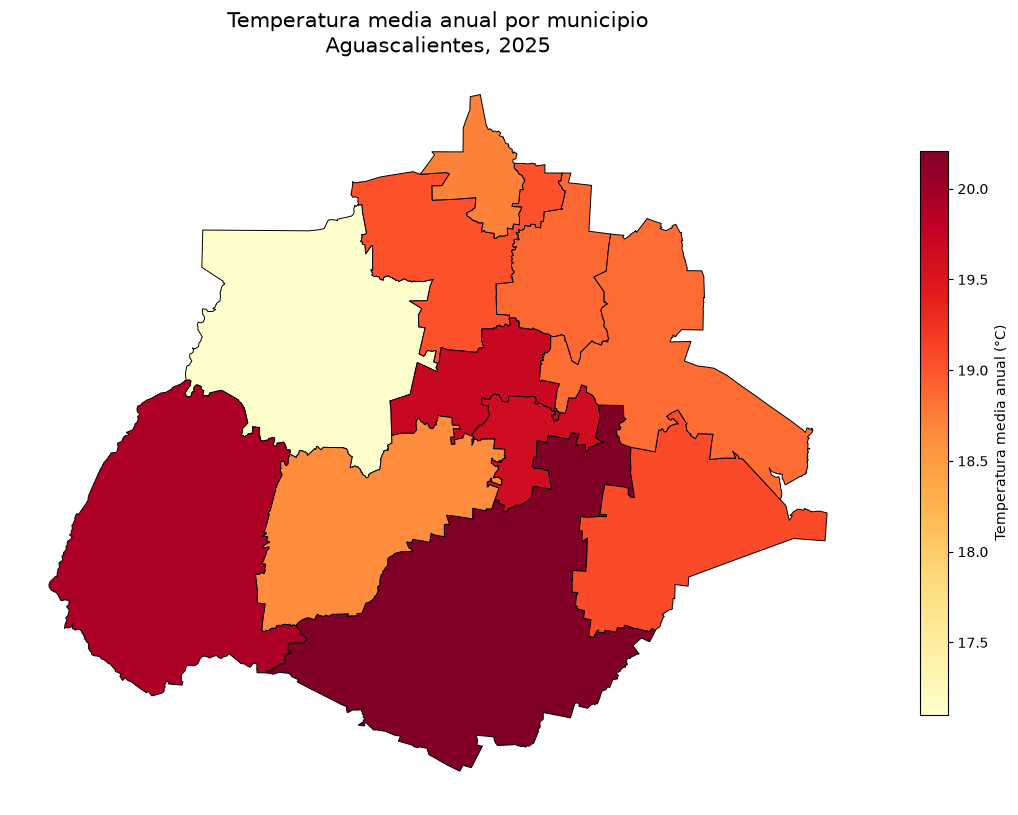

In [7]:
fig, ax = plt.subplots(figsize=(11, 9))

ags_clima_2025.plot(
    column="Temperatura_media",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.7,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos",
    },
    legend_kwds={
        "label": "Temperatura media anual (°C)",
        "shrink": 0.65,
    },
    ax=ax,
)

ax.set_title(
    "Temperatura media anual por municipio\n"
    "Aguascalientes, 2025",
    fontsize=15,
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Evolución espacial de la temperatura (2003–2025)

Se construirá una animación geoespacial con GeoPandas que representa
la temperatura media anual de los municipios de Aguascalientes.

Cada fotograma corresponde a un año del periodo 2003–2025.

Se utilizará una escala cromática fija para permitir comparaciones
temporales consistentes.

Las temperaturas corresponden a estimaciones climáticas obtenidas
en coordenadas representativas de cada municipio.

In [8]:
from matplotlib import animation
from IPython.display import Image, display

from proyecto_agronomia.config import PROJ_ROOT

# Asociar los 23 años climáticos con los polígonos municipales
ags_clima_geo = ags_geo.merge(
    clima_ags[
        ["Anio", "Idestado", "Idmunicipio", "Temperatura_media"]
    ],
    on=["Idestado", "Idmunicipio"],
    how="inner",
    validate="one_to_many",
)

# Orden cronológico
anios = sorted(ags_clima_geo["Anio"].unique())

# Escala constante para todos los años
vmin = ags_clima_geo["Temperatura_media"].min()
vmax = ags_clima_geo["Temperatura_media"].max()

print("Años:", anios[0], "-", anios[-1])
print("Observaciones:", len(ags_clima_geo))
print(f"Temperaturas: {vmin:.2f} °C a {vmax:.2f} °C")

Años: 2003 - 2025
Observaciones: 253
Temperaturas: 15.38 °C a 20.79 °C


In [9]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation, PillowWriter

# Carpeta de resultados
FIG_DIR = PROJ_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

GIF_PATH = FIG_DIR / "temperatura_aguascalientes_2003_2025.gif"

# Figura
fig, ax = plt.subplots(figsize=(9, 9))

# Escala de colores fija
cmap = plt.get_cmap("YlOrRd")
norm = Normalize(vmin=vmin, vmax=vmax)

# Barra de colores
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02,
    shrink=0.7,
)

cbar.set_label(
    "Temperatura media anual (°C)",
    fontsize=11,
)

# Límites geográficos constantes
xmin, ymin, xmax, ymax = ags_geo.total_bounds
margen_x = (xmax - xmin) * 0.05
margen_y = (ymax - ymin) * 0.05


def actualizar(frame):
    ax.clear()

    anio = anios[frame]

    datos_anio = ags_clima_geo[
        ags_clima_geo["Anio"] == anio
    ]

    datos_anio.plot(
        column="Temperatura_media",
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.6,
        ax=ax,
    )

    temperatura_promedio = (
        datos_anio["Temperatura_media"].mean()
    )

    ax.set_title(
        f"Aguascalientes | {anio}\n"
        f"Promedio municipal: {temperatura_promedio:.2f} °C",
        fontsize=15,
        fontweight="bold",
        pad=18,
    )

    ax.set_xlim(xmin - margen_x, xmax + margen_x)
    ax.set_ylim(ymin - margen_y, ymax + margen_y)
    ax.set_aspect("equal")
    ax.set_axis_off()

    return []


animacion = FuncAnimation(
    fig,
    actualizar,
    frames=len(anios),
    interval=650,
    repeat=True,
)

# Guardar GIF
animacion.save(
    GIF_PATH,
    writer=PillowWriter(fps=2),
    dpi=110,
)

plt.close(fig)

print("GIF generado:")
print(GIF_PATH)

GIF generado:
B:\MCD2\JW\agro\proyecto_agronomia\reports\figures\temperatura_aguascalientes_2003_2025.gif


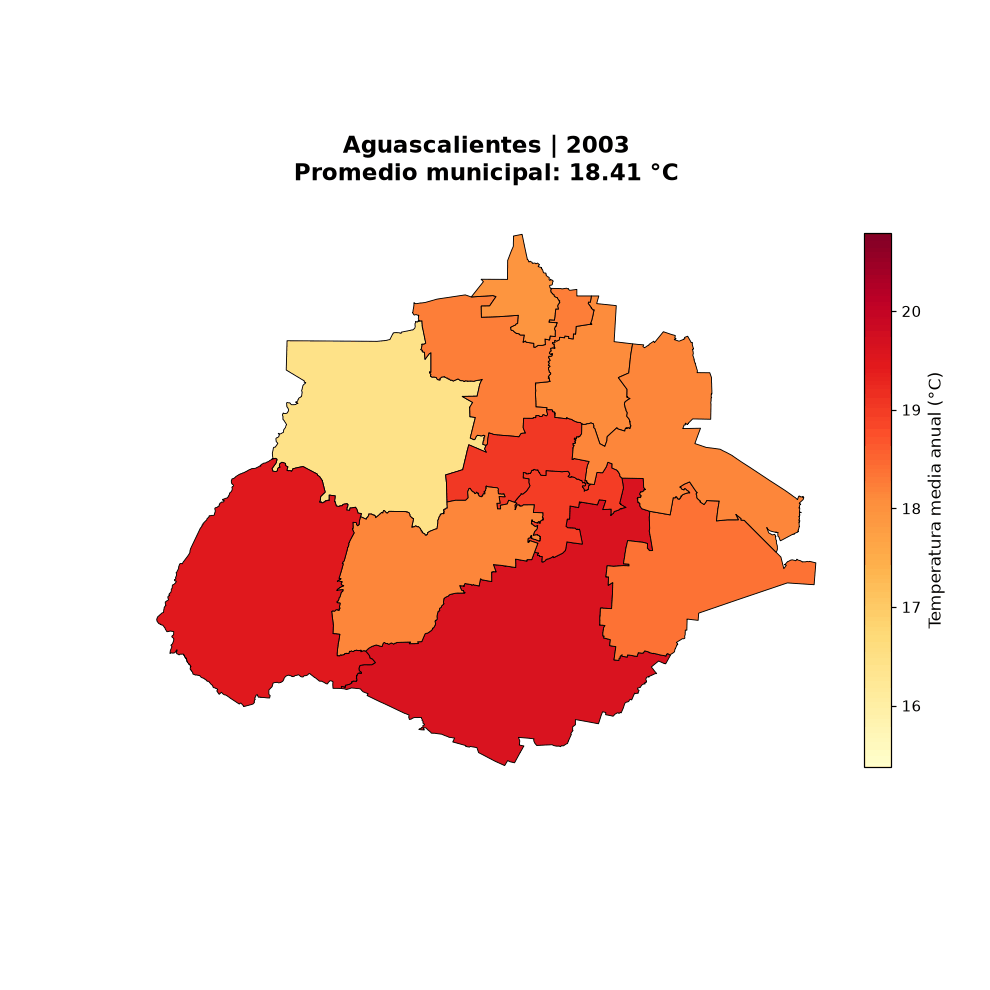

In [10]:
display(Image(filename=str(GIF_PATH)))